# Variance Ratio Demo

This notebook checks the variance gain from aggregating one hyperoctahedral frequency orbit.

For an $n$-qubit circuit with $L$ upload layers, the frequency spectrum is
$$
\Omega=\llbracket-M,M\rrbracket^n,
$$
where $M$ is the maximum frequency in one coordinate.

The symmetry group is
$$
\mathbb Z_2^n \rtimes S_n,
$$
which acts by sign flips and coordinate permutations.

The orbit frequency spectrum is the set of sorted nonnegative representatives
$$
\widetilde{\Omega}=
\{(\nu_1,\ldots,\nu_n):0\leq \nu_1\leq \cdots\leq \nu_n\leq M\}.
$$
Its size is
$$
|\widetilde{\Omega}|=\binom{M+n}{n}.
$$

The variance experiment uses one selected orbit frequency $\nu_n$. By default the notebook uses
$$
\nu_n=(1,2,\ldots,n),
$$
provided $M\geq n$. The aggregated coefficient is
$$
a_{\nu_n}=\sum_{\omega\in[\nu_n]}c_\omega.
$$

The plotted ratio is
$$
\rho_n=
\frac{\operatorname{Var}_\theta(a_{\nu_n})}
{\overline{\operatorname{Var}_\theta(c_\omega)}_{\omega\in[\nu_n]}}.
$$
Under ideal 2-design decoupling, $\rho_n$ should be close to the selected orbit size $|[\nu_n]|$.


In [167]:
from dataclasses import dataclass
from pathlib import Path
from typing import Optional
import itertools
import math
import time

import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import torch


def paper_work_dir():
    cwd = Path.cwd()
    for candidate in (cwd, *cwd.parents):
        if candidate.name == "Paper_work":
            return candidate
        if (candidate / "Paper_work").is_dir():
            return candidate / "Paper_work"
    return cwd


PAPER_WORK = paper_work_dir()
FIGURE_PATH = PAPER_WORK / "MSQE" / "figures" / "variance_ratio.png"
RESULTS_PATH = PAPER_WORK / "MSQE" / "figures" / "variance_ratio_results.npz"

# Change these top-level knobs; both B=n and B=1 settings below use them.
# For the hyperoctahedral orbit below, n needs n distinct positive frequencies.
# With base-3 exponential uploading this requires (3**N_UPLOAD_LAYERS - 1)//2 >= max(QUBIT_COUNTS).
QUBIT_COUNTS = (1, 2, 3, 4)
N_UPLOAD_LAYERS = 1
ENCODING_BASE = 3
N_PARAMETER_SAMPLES = 96
MAX_GRID_POINTS = 1_000_000
SELECTED_ORBIT_FREQUENCY = None  # None means use (1, 2, ..., n).


def binomial(n, k):
    if hasattr(math, "comb"):
        return math.comb(n, k)
    return math.factorial(n) // (math.factorial(k) * math.factorial(n - k))


@dataclass
class ExperimentConfig:
    qubit_counts: tuple = QUBIT_COUNTS
    n_upload_layers: int = N_UPLOAD_LAYERS
    encoding_base: int = ENCODING_BASE
    n_parameter_samples: int = N_PARAMETER_SAMPLES
    blocks_per_trainable_layer: object = None
    selected_orbit_frequency: object = SELECTED_ORBIT_FREQUENCY
    setting_name: str = "deeper setting"
    seed: int = 20260521
    prefer_mps: bool = True
    max_grid_points: int = MAX_GRID_POINTS
    real_dtype: torch.dtype = torch.float32
    complex_dtype: torch.dtype = torch.complex64

    @property
    def omega_max(self):
        return sum(self.encoding_base**layer for layer in range(self.n_upload_layers))

    @property
    def nx(self):
        # Nyquist grid for integer frequencies in [-omega_max, omega_max].
        return 2 * self.omega_max + 1


CONFIG = ExperimentConfig(
    qubit_counts=QUBIT_COUNTS,
    n_upload_layers=N_UPLOAD_LAYERS,
    encoding_base=ENCODING_BASE,
    n_parameter_samples=N_PARAMETER_SAMPLES,
    max_grid_points=MAX_GRID_POINTS,
    setting_name=r"StrongEntangle blocks, $B=n$",
)
BLOCK1_CONFIG = ExperimentConfig(
    qubit_counts=CONFIG.qubit_counts,
    n_upload_layers=CONFIG.n_upload_layers,
    encoding_base=CONFIG.encoding_base,
    n_parameter_samples=CONFIG.n_parameter_samples,
    blocks_per_trainable_layer=1,
    selected_orbit_frequency=CONFIG.selected_orbit_frequency,
    setting_name=r"StrongEntangle blocks, $B=1$",
    seed=CONFIG.seed + 2718,
    prefer_mps=CONFIG.prefer_mps,
    max_grid_points=CONFIG.max_grid_points,
    real_dtype=CONFIG.real_dtype,
    complex_dtype=CONFIG.complex_dtype,
)
mpl.rcParams.update({
    "font.size": 15,
    "axes.labelsize": 17,
    "axes.titlesize": 18,
    "xtick.labelsize": 14,
    "ytick.labelsize": 14,
    "legend.fontsize": 13,
    "axes.linewidth": 1.15,
    "figure.dpi": 140,
})

In [168]:
def complex_exp(angle):
    """Return exp(i * angle) without relying on Python complex scalar promotion."""
    return torch.complex(torch.cos(angle), torch.sin(angle))


def choose_torch_device(prefer_mps=True):
    candidates = []
    if prefer_mps and torch.backends.mps.is_available():
        candidates.append("mps")
    if torch.cuda.is_available():
        candidates.append("cuda")
    candidates.append("cpu")

    for name in candidates:
        device = torch.device(name)
        try:
            test = torch.eye(2, dtype=torch.complex64, device=device)
            batch = torch.ones((4, 2), dtype=torch.complex64, device=device)
            index = torch.tensor([1, 0], dtype=torch.long, device=device)
            _ = (test @ test).real.sum().item()
            _ = torch.matmul(batch, test.T).real.sum().item()
            _ = torch.index_select(batch, -1, index).real.sum().item()
            return device
        except Exception as exc:
            print(f"Skipping {name}: complex matmul is unavailable ({exc})")
    return torch.device("cpu")


DEVICE = choose_torch_device(CONFIG.prefer_mps)
print(f"Using torch device: {DEVICE}")
print(f"grid size per n: Nx = {CONFIG.nx}, omega_max = {CONFIG.omega_max}")

Skipping mps: complex matmul is unavailable (Trying to convert ComplexFloat to the MPS backend but it does not have support for that dtype.)
Using torch device: cpu
grid size per n: Nx = 3, omega_max = 1


## Batched Statevector Simulator

The original notebook evaluated one PennyLane QNode for every grid point and every parameter sample. Here the whole input grid is propagated as a batch of statevectors. This is much faster for the small-to-medium systems used in this coefficient variance check, and it can use `mps` if the local PyTorch build supports the required complex operations.

In [169]:
def basis_bits(n_qubits, device):
    # Precompute bit tables on CPU. This avoids MPS integer bitwise-kernel limitations.
    dim = 2**n_qubits
    bits = np.array(
        [[(basis >> (n_qubits - 1 - wire)) & 1 for wire in range(n_qubits)] for basis in range(dim)],
        dtype=np.int64,
    )
    return torch.tensor(bits, dtype=torch.long, device=device)


def input_grid(n_qubits, nx, device, dtype):
    values = torch.linspace(0.0, 2.0 * math.pi, nx + 1, dtype=dtype)[:-1]
    points = torch.cartesian_prod(*([values] * n_qubits))
    if points.ndim == 1:
        points = points[:, None]
    return points.to(device)


def initial_states(n_grid, n_qubits, device, complex_dtype):
    states = torch.zeros((n_grid, 2**n_qubits), dtype=complex_dtype, device=device)
    states[:, 0] = 1.0 + 0.0j
    return states


def rz_gate(theta, complex_dtype):
    diagonal = torch.stack([complex_exp(-0.5 * theta), complex_exp(0.5 * theta)]).to(complex_dtype)
    return torch.diag(diagonal)


def ry_gate(theta, complex_dtype):
    c = torch.cos(0.5 * theta)
    s = torch.sin(0.5 * theta)
    return torch.stack([
        torch.stack([c, -s]),
        torch.stack([s, c]),
    ]).to(complex_dtype)


def rot_gate(phi, theta, omega, complex_dtype):
    # PennyLane Rot(phi, theta, omega) = RZ(omega) RY(theta) RZ(phi).
    return rz_gate(omega, complex_dtype) @ ry_gate(theta, complex_dtype) @ rz_gate(phi, complex_dtype)


def apply_single_qubit_gate(states, gate, wire, n_qubits):
    original_shape = states.shape
    tensor = states.reshape(-1, *([2] * n_qubits))
    tensor = torch.movedim(tensor, wire + 1, -1)
    tensor = torch.matmul(tensor, gate.T)
    tensor = torch.movedim(tensor, -1, wire + 1)
    return tensor.reshape(original_shape)


def cnot_gather_index(n_qubits, control, target, device):
    dim = 2**n_qubits
    gather = np.empty(dim, dtype=np.int64)
    for old_index in range(dim):
        bits = [(old_index >> (n_qubits - 1 - wire)) & 1 for wire in range(n_qubits)]
        new_bits = bits.copy()
        if bits[control] == 1:
            new_bits[target] ^= 1
        new_index = 0
        for bit in new_bits:
            new_index = (new_index << 1) | bit
        gather[new_index] = old_index
    return torch.tensor(gather, dtype=torch.long, device=device)


def entangler_pairs(n_qubits, block_index):
    if n_qubits <= 1:
        return []
    entangling_range = (block_index % (n_qubits - 1)) + 1
    return [(wire, (wire + entangling_range) % n_qubits) for wire in range(n_qubits)]


def apply_trainable_layer(states, weights_layer, cnot_cache, n_qubits, complex_dtype):
    n_blocks = weights_layer.shape[0]
    for block in range(n_blocks):
        for wire in range(n_qubits):
            phi, theta, omega = weights_layer[block, wire]
            gate = rot_gate(phi, theta, omega, complex_dtype)
            states = apply_single_qubit_gate(states, gate, wire, n_qubits)
        for control, target in entangler_pairs(n_qubits, block):
            states = torch.index_select(states, -1, cnot_cache[(control, target)])
    return states


def encoding_signs(n_qubits, device, dtype):
    bits = basis_bits(n_qubits, device).to(dtype)
    return bits - 0.5


def apply_data_encoding(states, grid, signs, beta):
    # RZ(beta * x_j) on wire j gives phase exp(i * beta * x_j * (bit_j - 1/2)).
    phase_angles = (beta * grid) @ signs.T
    return states * complex_exp(phase_angles).to(states.dtype)


def local_projector_observable_diag(n_qubits, device, dtype):
    # O = (1/n) sum_j |0><0|_j is diagonal; value is the fraction of zero bits.
    bits = basis_bits(n_qubits, device).to(dtype)
    return 1.0 - bits.mean(dim=1)


def observable_expectation(states, observable_diag):
    probabilities = states.abs().square()
    return probabilities @ observable_diag

In [ ]:
def trainable_block_count(n_qubits, config):
    rule = config.blocks_per_trainable_layer
    if rule is None or rule == "n":
        return max(int(n_qubits), 1)
    if callable(rule):
        return max(int(rule(n_qubits)), 1)
    return max(int(rule), 1)


def make_cache(n_qubits, config, device):
    n_grid = config.nx**n_qubits
    if n_grid > config.max_grid_points:
        raise ValueError(
            f"Grid has {n_grid:,} points for n={n_qubits}. "
            f"Reduce qubit_counts, n_upload_layers, or raise max_grid_points."
        )

    n_blocks = trainable_block_count(n_qubits, config)
    cnot_cache = {
        pair: cnot_gather_index(n_qubits, pair[0], pair[1], device)
        for block in range(n_blocks)
        for pair in entangler_pairs(n_qubits, block)
    }
    return {
        "grid": input_grid(n_qubits, config.nx, device, config.real_dtype),
        "signs": encoding_signs(n_qubits, device, config.real_dtype),
        "observable_diag": local_projector_observable_diag(n_qubits, device, config.real_dtype),
        "cnot_cache": cnot_cache,
    }


def random_weights(n_qubits, config, generator, device):
    n_blocks = trainable_block_count(n_qubits, config)
    shape = (config.n_upload_layers + 1, n_blocks, n_qubits, 3)
    weights = 2.0 * math.pi * torch.rand(shape, generator=generator, dtype=config.real_dtype)
    return weights.to(device)


def evaluate_function_grid(n_qubits, weights, cache, config, device):
    grid = cache["grid"]
    states = initial_states(grid.shape[0], n_qubits, device, config.complex_dtype)

    states = apply_trainable_layer(
        states, weights[0], cache["cnot_cache"], n_qubits, config.complex_dtype
    )
    for layer in range(config.n_upload_layers):
        beta = config.encoding_base**layer
        states = apply_data_encoding(states, grid, cache["signs"], beta)
        states = apply_trainable_layer(
            states, weights[layer + 1], cache["cnot_cache"], n_qubits, config.complex_dtype
        )

    values = observable_expectation(states, cache["observable_diag"])
    return values.reshape((config.nx,) * n_qubits).detach().cpu().numpy()


def coefficient_tensor(function_grid):
    # If f(x)=sum_omega c_omega exp(-i omega.x), ifftn gives c_omega on the integer grid.
    return np.fft.ifftn(function_grid)


def coefficient_at(coeffs, omega):
    idx = tuple(int(w) % coeffs.shape[axis] for axis, w in enumerate(omega))
    return coeffs[idx]

## PennyLane Equivalence Check

This diagnostic checks that the custom batched Torch simulator implements the same circuit as PennyLane's `StronglyEntanglingLayers` for the settings used below. It compares expectation values for the same inputs and the same random trainable weights.

In [170]:
def evaluate_custom_points(n_qubits, x_points, weights, config, device):
    x_points = np.asarray(x_points, dtype=float)
    if x_points.ndim == 1:
        x_points = x_points[None, :]
    grid = torch.tensor(x_points, dtype=config.real_dtype, device=device)

    n_blocks = trainable_block_count(n_qubits, config)
    cnot_cache = {
        pair: cnot_gather_index(n_qubits, pair[0], pair[1], device)
        for block in range(n_blocks)
        for pair in entangler_pairs(n_qubits, block)
    }
    signs = encoding_signs(n_qubits, device, config.real_dtype)
    observable_diag = local_projector_observable_diag(n_qubits, device, config.real_dtype)

    states = initial_states(grid.shape[0], n_qubits, device, config.complex_dtype)
    states = apply_trainable_layer(states, weights[0], cnot_cache, n_qubits, config.complex_dtype)
    for layer in range(config.n_upload_layers):
        beta = config.encoding_base**layer
        states = apply_data_encoding(states, grid, signs, beta)
        states = apply_trainable_layer(states, weights[layer + 1], cnot_cache, n_qubits, config.complex_dtype)

    return observable_expectation(states, observable_diag).detach().cpu().numpy()


def pennylane_point_values(n_qubits, x_points, weights, config):
    import pennylane as qml

    x_points = np.asarray(x_points, dtype=float)
    if x_points.ndim == 1:
        x_points = x_points[None, :]
    weights_np = weights.detach().cpu().numpy()
    observable_diag = local_projector_observable_diag(n_qubits, torch.device("cpu"), torch.float64).numpy()
    observable_matrix = np.diag(observable_diag)
    wires = list(range(n_qubits))
    strongly_entangling = qml.templates.StronglyEntanglingLayers

    dev = qml.device("default.qubit", wires=n_qubits)

    @qml.qnode(dev)
    def circuit(x_vec, trainable_weights):
        strongly_entangling(trainable_weights[0], wires=wires)
        for layer in range(config.n_upload_layers):
            beta = config.encoding_base**layer
            for wire in wires:
                qml.RZ(beta * x_vec[wire], wires=wire)
            strongly_entangling(trainable_weights[layer + 1], wires=wires)
        return qml.expval(qml.Hermitian(observable_matrix, wires=wires))

    return np.array([float(circuit(x_vec, weights_np)) for x_vec in x_points], dtype=float)


def verify_pennylane_equivalence(tolerance=5e-5):
    n_qubits = 3
    x_points = np.array(
        [
            [0.10, 0.70, 1.30],
            [1.20, 2.10, 0.40],
            [2.70, 0.30, 3.00],
            [5.10, 4.20, 1.70],
        ],
        dtype=float,
    )
    settings = [
        (r"B=n", CONFIG),
        (r"B=1", BLOCK1_CONFIG),
    ]

    for label, config in settings:
        generator = torch.Generator(device="cpu")
        generator.manual_seed(config.seed + 12345)
        weights = random_weights(n_qubits, config, generator, DEVICE)
        custom_values = evaluate_custom_points(n_qubits, x_points, weights, config, DEVICE)
        pennylane_values = pennylane_point_values(n_qubits, x_points, weights, config)
        abs_error = np.abs(custom_values - pennylane_values)
        print(f"{label}: max |custom - PennyLane| = {abs_error.max():.3e}")
        print(np.column_stack([custom_values, pennylane_values, abs_error]))
        assert abs_error.max() < tolerance, f"{label} mismatch: {abs_error.max():.3e}"


verify_pennylane_equivalence()


B=n: max |custom - PennyLane| = 2.107e-07
[[5.62613785e-01 5.62613845e-01 5.95621429e-08]
 [4.91571248e-01 4.91571198e-01 4.99456321e-08]
 [5.08739173e-01 5.08738963e-01 2.10651633e-07]
 [4.62264121e-01 4.62264283e-01 1.62260097e-07]]
B=1: max |custom - PennyLane| = 7.479e-08
[[3.03362995e-01 3.03362993e-01 2.32122066e-09]
 [4.42393392e-01 4.42393467e-01 7.47907992e-08]
 [4.91716743e-01 4.91716752e-01 9.05650804e-09]
 [3.00507337e-01 3.00507290e-01 4.72698848e-08]]


## Orbit Statistics

The symmetry group is the hyperoctahedral group $\mathbb Z_2^n \rtimes S_n$: sign flips plus coordinate permutations.

For frequency spectrum $\Omega=\llbracket-M,M\rrbracket^n$, the orbit frequency spectrum is
$$
\widetilde{\Omega}=
\{(\nu_1,\ldots,\nu_n):0\leq \nu_1\leq \cdots\leq \nu_n\leq M\},
$$
with size
$$
|\widetilde{\Omega}|=\binom{M+n}{n}.
$$

For any orbit frequency $\nu\in\widetilde{\Omega}$, the orbit $[\nu]$ is generated by all sign flips and coordinate permutations. Zeros and repeated entries reduce the orbit size.

The variance experiment uses the selected orbit frequency $\nu_n$ and computes
$$
a_{\nu_n}=\sum_{\omega\in[\nu_n]}c_\omega.
$$

The denominator of the ratio is estimated by averaging the empirical variances of the individual $c_\omega$ over $\omega\in[\nu_n]$.


In [171]:
def upload_betas(config):
    return tuple(int(config.encoding_base**layer) for layer in range(config.n_upload_layers))


def coordinate_frequency_values(config):
    values = {0}
    for beta in upload_betas(config):
        values = {freq + sign * beta for freq in values for sign in (-1, 0, 1)}
    return tuple(sorted(values))


# Backward-compatible alias used by older cells or interactive work.
def single_coordinate_frequency_values(config):
    return coordinate_frequency_values(config)


def max_frequency(config):
    return max(abs(freq) for freq in coordinate_frequency_values(config))


def orbit_frequency_spectrum(n_qubits, config):
    return list(itertools.combinations_with_replacement(range(max_frequency(config) + 1), n_qubits))


def orbit_frequency_spectrum_size(n_qubits, config):
    return binomial(max_frequency(config) + n_qubits, n_qubits)


def canonical_orbit_frequency(frequency):
    return tuple(sorted(abs(int(freq)) for freq in frequency))


def selected_orbit_frequency(n_qubits, config):
    if config.selected_orbit_frequency is None:
        frequency = tuple(range(1, n_qubits + 1))
    else:
        frequency = canonical_orbit_frequency(config.selected_orbit_frequency)
        if len(frequency) != n_qubits:
            raise ValueError(
                f"SELECTED_ORBIT_FREQUENCY has length {len(frequency)}, but n={n_qubits}."
            )
    M = max_frequency(config)
    if frequency[-1] > M:
        raise ValueError(
            f"Selected orbit frequency {frequency} needs max frequency {frequency[-1]}, "
            f"but the spectrum only reaches M={M}. Increase N_UPLOAD_LAYERS or choose another orbit."
        )
    return frequency


def hyperoctahedral_orbit(orbit_frequency):
    orbit_frequency = tuple(int(freq) for freq in orbit_frequency)
    orbit = set()
    for permuted in itertools.permutations(orbit_frequency):
        for signs in itertools.product((-1, 1), repeat=len(orbit_frequency)):
            orbit.add(tuple(0 if freq == 0 else sign * freq for sign, freq in zip(signs, permuted)))
    return sorted(orbit)


def orbit_size_formula(orbit_frequency):
    counts = {}
    for freq in orbit_frequency:
        counts[freq] = counts.get(freq, 0) + 1
    zero_count = counts.get(0, 0)
    denominator = 1
    for multiplicity in counts.values():
        denominator *= math.factorial(multiplicity)
    return (2 ** (len(orbit_frequency) - zero_count)) * math.factorial(len(orbit_frequency)) // denominator


def format_frequency_collection(values, max_listed=80):
    values = list(values)
    if max_listed is None or len(values) <= max_listed:
        return str(values)
    head_count = max_listed // 2
    tail_count = max_listed - head_count
    return f"{values[:head_count]} ... {values[-tail_count:]} (total {len(values)})"


def print_frequency_orbit_definition(
    n_qubits,
    config,
    max_orbit_frequencies_listed=120,
    max_orbit_elements_listed=80,
):
    M = max_frequency(config)
    orbit_frequency_reps = orbit_frequency_spectrum(n_qubits, config)
    selected_frequency = selected_orbit_frequency(n_qubits, config)
    selected_orbit = hyperoctahedral_orbit(selected_frequency)

    print(f"n={n_qubits}, L={config.n_upload_layers}")
    print(f"max frequency in frequency spectrum = {M}")
    print(f"frequency spectrum Omega = [[-{M}, {M}]]^{n_qubits}")
    print(f"orbit frequency spectrum size = {len(orbit_frequency_reps)} = C({M}+{n_qubits}, {n_qubits})")
    print(
        "orbit frequency spectrum = "
        f"{format_frequency_collection(orbit_frequency_reps, max_listed=max_orbit_frequencies_listed)}"
    )
    print("orbit frequency -> orbit:")
    for orbit_frequency in orbit_frequency_reps[:max_orbit_frequencies_listed]:
        orbit = hyperoctahedral_orbit(orbit_frequency)
        formula_size = orbit_size_formula(orbit_frequency)
        print(f"  {orbit_frequency}: orbit size = {len(orbit)}")
        if len(orbit) != formula_size:
            print(f"    warning: formula gives {formula_size}")
        print(f"    orbit = {format_frequency_collection(orbit, max_listed=max_orbit_elements_listed)}")
    if len(orbit_frequency_reps) > max_orbit_frequencies_listed:
        print(f"  ... omitted {len(orbit_frequency_reps) - max_orbit_frequencies_listed} orbit frequencies")
    print(
        f"variance experiment uses orbit frequency nu_{n_qubits} = {selected_frequency}, "
        f"orbit size = {len(selected_orbit)}"
    )
    print()


def coefficient_vector_for_orbit(coeffs, orbit):
    orbit_array = np.array(orbit, dtype=int)
    indices = tuple((orbit_array[:, axis] % coeffs.shape[axis]).astype(int) for axis in range(orbit_array.shape[1]))
    return coeffs[indices]


def complex_sample_variance(samples, axis=0):
    centered = samples - np.mean(samples, axis=axis, keepdims=True)
    return np.mean(np.abs(centered) ** 2, axis=axis)


def orbit_variance_statistics(n_qubits, config, device):
    n_blocks = trainable_block_count(n_qubits, config)
    cache = make_cache(n_qubits, config, device)
    generator = torch.Generator(device="cpu")
    generator.manual_seed(config.seed + 10_000 * n_qubits)

    frequency_values = coordinate_frequency_values(config)
    base_frequency = selected_orbit_frequency(n_qubits, config)
    orbit = hyperoctahedral_orbit(base_frequency)
    orbit_size = len(orbit)

    coefficient_sum = np.zeros(orbit_size, dtype=np.complex128)
    coefficient_abs2_sum = np.zeros(orbit_size, dtype=np.float64)
    aggregate_samples = np.zeros(config.n_parameter_samples, dtype=np.complex128)

    start = time.perf_counter()
    with torch.no_grad():
        for sample in range(config.n_parameter_samples):
            weights = random_weights(n_qubits, config, generator, device)
            f_grid = evaluate_function_grid(n_qubits, weights, cache, config, device)
            coeffs = coefficient_tensor(f_grid)
            coeff_vector = coefficient_vector_for_orbit(coeffs, orbit)
            coefficient_sum += coeff_vector
            coefficient_abs2_sum += np.abs(coeff_vector) ** 2
            aggregate_samples[sample] = np.sum(coeff_vector)

    coefficient_mean = coefficient_sum / config.n_parameter_samples
    coefficient_variances = coefficient_abs2_sum / config.n_parameter_samples - np.abs(coefficient_mean) ** 2
    coefficient_variances = np.maximum(coefficient_variances.real, 0.0)
    aggregate_variance = float(complex_sample_variance(aggregate_samples, axis=0))
    mean_coefficient_variance = float(np.mean(coefficient_variances))
    sum_coefficient_variance = float(np.sum(coefficient_variances))
    ratio = float(aggregate_variance / mean_coefficient_variance) if mean_coefficient_variance > 0 else np.nan
    decoupling_ratio = (
        float(aggregate_variance / sum_coefficient_variance)
        if sum_coefficient_variance > 0
        else np.nan
    )

    return {
        "n_qubits": n_qubits,
        "n_upload_layers": config.n_upload_layers,
        "encoding_base": config.encoding_base,
        "frequency_values": frequency_values,
        "max_frequency": max_frequency(config),
        "orbit_frequency_spectrum_size": orbit_frequency_spectrum_size(n_qubits, config),
        "variance_orbit_frequency": f"nu_{n_qubits}",
        "base_orbit_frequency": base_frequency,
        "symmetry": "hyperoctahedral group Z_2^n semidirect S_n",
        "setting": config.setting_name,
        "trainable_blocks": n_blocks,
        "orbit_size": orbit_size,
        "ratio": ratio,
        "ideal_ratio": orbit_size,
        "aggregate_variance": aggregate_variance,
        "mean_coefficient_variance": mean_coefficient_variance,
        "sum_coefficient_variance": sum_coefficient_variance,
        "decoupling_ratio": decoupling_ratio,
        "elapsed_seconds": time.perf_counter() - start,
    }


def run_variance_ratio_experiment(config=CONFIG, device=DEVICE):
    print(f"\nRunning {config.setting_name}")
    results = []
    for n_qubits in config.qubit_counts:
        stats = orbit_variance_statistics(n_qubits, config, device)
        results.append(stats)
        print(
            f"n={n_qubits:2d} | blocks={stats['trainable_blocks']:2d} | "
            f"orbit frequency={stats['variance_orbit_frequency']}={stats['base_orbit_frequency']} | "
            f"orbit size={stats['orbit_size']:7d} | "
            f"orbit frequency spectrum size={stats['orbit_frequency_spectrum_size']:7d} | "
            f"ratio={stats['ratio']:9.3f} | ratio/orbit={stats['ratio']/stats['orbit_size']:7.3f} | "
            f"Var(a)/sum Var(c)={stats['decoupling_ratio']:7.3f} | "
            f"time={stats['elapsed_seconds']:6.2f}s"
        )
    return results


## Frequencies Used in the Experiment

The helper below prints, for every $n$ in `CONFIG.qubit_counts`:

- max frequency $M$ in the frequency spectrum,
- the orbit frequency spectrum $\widetilde{\Omega}$,
- the orbit frequency spectrum size $\binom{M+n}{n}$,
- every displayed orbit frequency and its corresponding orbit,
- which orbit frequency is used for the variance experiment.

The figures use the selected orbit frequency $\nu_n$. By default this is $(1,2,\ldots,n)$.


In [172]:
def print_observed_frequency_orbits(
    qubit_counts=CONFIG.qubit_counts,
    config=CONFIG,
    max_orbit_frequencies_listed=120,
    max_orbit_elements_listed=80,
):
    for n_qubits in qubit_counts:
        print_frequency_orbit_definition(
            n_qubits,
            config,
            max_orbit_frequencies_listed=max_orbit_frequencies_listed,
            max_orbit_elements_listed=max_orbit_elements_listed,
        )


print_observed_frequency_orbits()


n=1, L=1
max frequency in frequency spectrum = 1
frequency spectrum Omega = [[-1, 1]]^1
orbit frequency spectrum size = 2 = C(1+1, 1)
orbit frequency spectrum = [(0,), (1,)]
orbit frequency -> orbit:
  (0,): orbit size = 1
    orbit = [(0,)]
  (1,): orbit size = 2
    orbit = [(-1,), (1,)]
variance experiment uses orbit frequency nu_1 = (1,), orbit size = 2


ValueError: Selected orbit frequency (1, 2) needs max frequency 2, but the spectrum only reaches M=1. Increase N_UPLOAD_LAYERS or choose another orbit.

In [ ]:
results_blocks_n = run_variance_ratio_experiment(CONFIG, DEVICE)
results_blocks_1 = run_variance_ratio_experiment(BLOCK1_CONFIG, DEVICE)

# Convenience alias used only for quick interactive inspection.
results = results_blocks_n
result_sets = {
    "blocks_n": results_blocks_n,
    "blocks_1": results_blocks_1,
}


In [ ]:
def result_arrays(results):
    return {
        "n": np.array([item["n_qubits"] for item in results], dtype=float),
        "orbit": np.array([item["ideal_ratio"] for item in results], dtype=float),
        "ratio": np.array([item["ratio"] for item in results], dtype=float),
        "mean_c": np.array([item["mean_coefficient_variance"] for item in results], dtype=float),
        "sum_c": np.array([item.get("sum_coefficient_variance", item["ideal_ratio"] * item["mean_coefficient_variance"]) for item in results], dtype=float),
        "var_a": np.array([item["aggregate_variance"] for item in results], dtype=float),
        "decoupling": np.array([item.get("decoupling_ratio", np.nan) for item in results], dtype=float),
    }


def plot_variance_ratio(results_blocks_n, results_blocks_1=None, output_path=FIGURE_PATH):
    blocks_n = result_arrays(results_blocks_n)

    fig, ax = plt.subplots(figsize=(6.8, 4.6), constrained_layout=True)
    ax.plot(
        blocks_n["n"],
        blocks_n["orbit"],
        "--",
        color="#1E4E8C",
        linewidth=2.1,
        label=r"selected orbit size $|[\nu_n]|$",
    )
    ax.plot(
        blocks_n["n"],
        blocks_n["ratio"],
        "o-",
        color="#B84A62",
        markerfacecolor="#D56A7D",
        markeredgecolor="white",
        markeredgewidth=0.8,
        linewidth=2.4,
        markersize=7.0,
        label=results_blocks_n[0].get("setting", r"StrongEntangle blocks, $B=n$"),
    )
    if results_blocks_1 is not None:
        block1 = result_arrays(results_blocks_1)
        ax.plot(
            block1["n"],
            block1["ratio"],
            "^-",
            color="#2F6F4E",
            markerfacecolor="#55A36A",
            markeredgecolor="white",
            markeredgewidth=0.8,
            linewidth=2.25,
            markersize=7.0,
            label=results_blocks_1[0].get("setting", "approx setting"),
        )

    ax.set_yscale("log", base=2)
    ax.set_xlabel("Number of qubits n")
    ax.set_ylabel(r"Variance ratio $\rho_n$")
    ax.set_title("Variance ratio")
    ax.grid(True, which="both", linewidth=0.45, alpha=0.55)
    ax.legend(loc="upper left", frameon=True, framealpha=0.95)
    ax.set_xticks(blocks_n["n"].astype(int))

    output_path.parent.mkdir(parents=True, exist_ok=True)
    fig.savefig(output_path, dpi=300, bbox_inches="tight")
    plt.show()
    print(f"saved figure to {output_path}")


plot_variance_ratio(results_blocks_n, results_blocks_1)


In [ ]:
def save_results(results, output_path=RESULTS_PATH):
    output_path.parent.mkdir(parents=True, exist_ok=True)
    np.savez(
        output_path,
        n_qubits=np.array([item["n_qubits"] for item in results], dtype=int),
        n_upload_layers=np.array([item["n_upload_layers"] for item in results], dtype=int),
        encoding_base=np.array([item["encoding_base"] for item in results], dtype=int),
        frequency_values=np.array([item["frequency_values"] for item in results], dtype=object),
        max_frequency=np.array([item["max_frequency"] for item in results], dtype=int),
        orbit_frequency_spectrum_size=np.array([item["orbit_frequency_spectrum_size"] for item in results], dtype=int),
        variance_orbit_frequency=np.array([item["variance_orbit_frequency"] for item in results], dtype=object),
        base_orbit_frequency=np.array([item["base_orbit_frequency"] for item in results], dtype=object),
        trainable_blocks=np.array([item["trainable_blocks"] for item in results], dtype=int),
        orbit_size=np.array([item["orbit_size"] for item in results], dtype=int),
        ratio=np.array([item["ratio"] for item in results], dtype=float),
        aggregate_variance=np.array([item["aggregate_variance"] for item in results], dtype=float),
        mean_coefficient_variance=np.array([item["mean_coefficient_variance"] for item in results], dtype=float),
        sum_coefficient_variance=np.array([item["sum_coefficient_variance"] for item in results], dtype=float),
        decoupling_ratio=np.array([item["decoupling_ratio"] for item in results], dtype=float),
        setting=np.array([item["setting"] for item in results], dtype=object),
    )
    print(f"saved results to {output_path}")


save_results(results_blocks_n, RESULTS_PATH)
save_results(results_blocks_1, RESULTS_PATH.with_name("variance_ratio_results_blocks_1.npz"))


## Raw Variance Values

This plot shows $\operatorname{Var}(a_{\nu_n})$ and $\overline{\operatorname{Var}(c_\omega)}$ for $\omega\in[\nu_n]$.

The code also prints the frequency spectrum $\Omega$ and confirms which hyperoctahedral orbit frequency is used for the plotted variance.


Raw variance figure uses these hyperoctahedral orbit frequencies:
n=1, L=2
max frequency in frequency spectrum = 4
frequency spectrum Omega = [[-4, 4]]^1
orbit frequency spectrum size = 5 = C(4+1, 1)
orbit frequency spectrum = [(0,), (1,), (2,), (3,), (4,)]
orbit frequency -> orbit:
  (0,): orbit size = 1
    orbit = [(0,)]
  (1,): orbit size = 2
    orbit = [(-1,), (1,)]
  (2,): orbit size = 2
    orbit = [(-2,), (2,)]
  (3,): orbit size = 2
    orbit = [(-3,), (3,)]
  (4,): orbit size = 2
    orbit = [(-4,), (4,)]
variance experiment uses orbit frequency nu_1 = (1,), orbit size = 2

n=2, L=2
max frequency in frequency spectrum = 4
frequency spectrum Omega = [[-4, 4]]^2
orbit frequency spectrum size = 15 = C(4+2, 2)
orbit frequency spectrum = [(0, 0), (0, 1), (0, 2), (0, 3), (0, 4), (1, 1), (1, 2), (1, 3), (1, 4), (2, 2), (2, 3), (2, 4), (3, 3), (3, 4), (4, 4)]
orbit frequency -> orbit:
  (0, 0): orbit size = 1
    orbit = [(0, 0)]
  (0, 1): orbit size = 4
    orbit = [(-1, 0), (0, -1

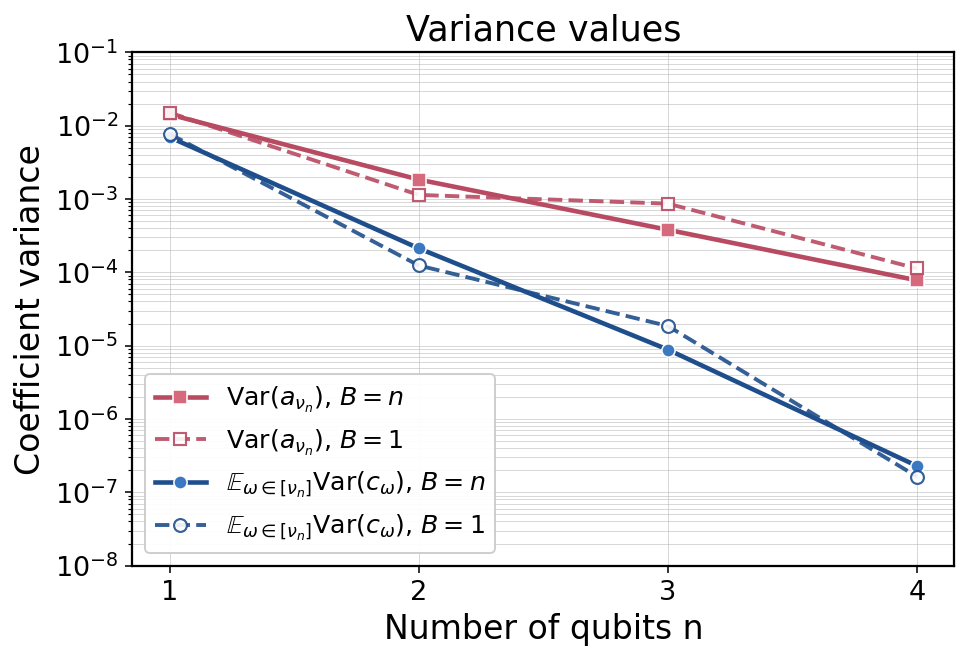

saved figure to /Users/letao/DataSpellProjects/quantum-fourier-expressivity/Paper_work/MSQE/figures/variance_values.png


In [164]:
def print_raw_variance_figure_nu(
    results,
    config=CONFIG,
    max_orbit_frequencies_listed=120,
    max_orbit_elements_listed=80,
):
    n_values = [int(item["n_qubits"]) for item in results]
    print("Raw variance figure uses these hyperoctahedral orbit frequencies:")
    for n_qubits in n_values:
        print_frequency_orbit_definition(
            n_qubits,
            config,
            max_orbit_frequencies_listed=max_orbit_frequencies_listed,
            max_orbit_elements_listed=max_orbit_elements_listed,
        )


def plot_raw_variances(results_blocks_n, results_blocks_1=None, output_path=None, config=CONFIG):
    if output_path is None:
        output_path = PAPER_WORK / "MSQE" / "figures" / "variance_values.png"

    print_raw_variance_figure_nu(results_blocks_n, config=config)
    blocks_n = result_arrays(results_blocks_n)

    fig, ax = plt.subplots(figsize=(6.8, 4.6), constrained_layout=True)
    line_var_a_n, = ax.plot(
        blocks_n["n"],
        blocks_n["var_a"],
        "s-",
        color="#B84A62",
        markerfacecolor="#D56A7D",
        markeredgecolor="white",
        markeredgewidth=0.8,
        linewidth=2.35,
        markersize=6.8,
        label=r"$\operatorname{Var}(a_{\nu_n})$, $B=n$",
    )
    visible_values = [blocks_n["var_a"], blocks_n["mean_c"]]

    line_var_a_1 = None
    line_mean_c_1 = None
    if results_blocks_1 is not None:
        block1 = result_arrays(results_blocks_1)
        line_var_a_1, = ax.plot(
            block1["n"],
            block1["var_a"],
            "s--",
            color="#B84A62",
            markerfacecolor="white",
            markeredgecolor="#B84A62",
            markeredgewidth=1.1,
            linewidth=2.0,
            markersize=6.6,
            alpha=0.9,
            label=r"$\operatorname{Var}(a_{\nu_n})$, $B=1$",
        )
        visible_values.append(block1["var_a"])

    line_mean_c_n, = ax.plot(
        blocks_n["n"],
        blocks_n["mean_c"],
        "o-",
        color="#1E4E8C",
        markerfacecolor="#3B78C2",
        markeredgecolor="white",
        markeredgewidth=0.8,
        linewidth=2.35,
        markersize=6.8,
        label=r"$\mathbb{E}_{\omega\in[\nu_n]}\operatorname{Var}(c_\omega)$, $B=n$",
    )

    if results_blocks_1 is not None:
        line_mean_c_1, = ax.plot(
            block1["n"],
            block1["mean_c"],
            "o--",
            color="#1E4E8C",
            markerfacecolor="white",
            markeredgecolor="#1E4E8C",
            markeredgewidth=1.1,
            linewidth=2.0,
            markersize=6.6,
            alpha=0.9,
            label=r"$\mathbb{E}_{\omega\in[\nu_n]}\operatorname{Var}(c_\omega)$, $B=1$",
        )
        visible_values.append(block1["mean_c"])

    positive_values = np.concatenate(visible_values)
    positive_values = positive_values[np.isfinite(positive_values) & (positive_values > 0)]
    if positive_values.size:
        y_min = 10 ** np.floor(np.log10(np.min(positive_values)) - 0.25)
        y_max = 10 ** np.ceil(np.log10(np.max(positive_values)) + 0.25)
        ax.set_ylim(y_min, y_max)

    ax.set_yscale("log")
    ax.set_xlabel("Number of qubits n")
    ax.set_ylabel("Coefficient variance")
    ax.set_title("Variance values")
    ax.grid(True, which="both", linewidth=0.45, alpha=0.55)

    handles = [line_var_a_n]
    if line_var_a_1 is not None:
        handles.append(line_var_a_1)
    handles.append(line_mean_c_n)
    if line_mean_c_1 is not None:
        handles.append(line_mean_c_1)
    ax.legend(handles=handles, loc="best", frameon=True, framealpha=0.95)
    ax.set_xticks(blocks_n["n"].astype(int))

    output_path.parent.mkdir(parents=True, exist_ok=True)
    fig.savefig(output_path, dpi=300, bbox_inches="tight")
    plt.show()
    print(f"saved figure to {output_path}")


plot_raw_variances(results_blocks_n, results_blocks_1, config=CONFIG)


## Theoretical Orbit-Size Scaling Demo

This optional cell is not a quantum circuit simulation. It is a coefficient-level check of the mechanism in the corollary.

For one hyperoctahedral orbit, the orbit-basis coefficient is defined as
$$
a_{\nu}=\sum_{\omega\in[\nu]} c_{\omega}.
$$
If the coefficients on the orbit are independent and have variance $b^{-n}$, then
$$
\operatorname{Var}(a_{\nu})=\sum_{\omega\in[\nu]}\operatorname{Var}(c_{\omega})=|[\nu]|b^{-n}.
$$

For the representative
$$
\nu_{n,k}=(1,2,\ldots,k,0,\ldots,0),
$$
the orbit has $k$ distinct nonzero coordinates and $n-k$ zero coordinates, so
$$
|[\nu_{n,k}]|=\frac{2^k n!}{(n-k)!}.
$$
The case $k=n$ is the special case $|[\nu_{n,n}]|=2^n n!$.

The plotted target is $|[\nu]|b^{-n}$. The optional polynomial floor $1/n^p$ is only a lower-bound reference; it is not expected to match the sampled variance unless $|[\nu]|$ is chosen to scale like $b^n/n^p$.


n | k | orbit size | Var(c_omega) exact | target Var(a_nu) | sampled/target | sampling
 1 |  1 |          2 |        3.3333e-01 |       6.6667e-01 |         1.0067 | explicit sum
 2 |  2 |          8 |        1.1111e-01 |       8.8889e-01 |         0.9891 | explicit sum
 3 |  3 |         48 |        3.7037e-02 |       1.7778e+00 |         0.9913 | explicit sum
 4 |  4 |        384 |        1.2346e-02 |       4.7407e+00 |         1.0110 | explicit sum
 5 |  5 |       3840 |        4.1152e-03 |       1.5802e+01 |         1.0430 | explicit sum
 6 |  6 |      46080 |        1.3717e-03 |       6.3210e+01 |         1.0123 | explicit sum
 7 |  7 |     645120 |        4.5725e-04 |       2.9498e+02 |         1.0188 | Gaussian sum law
 8 |  8 |   10321920 |        1.5242e-04 |       1.5732e+03 |         0.9819 | Gaussian sum law
 9 |  9 |  185794560 |        5.0805e-05 |       9.4393e+03 |         0.9823 | Gaussian sum law
10 | 10 | 3715891200 |        1.6935e-05 |       6.2929e+04 |         0.9

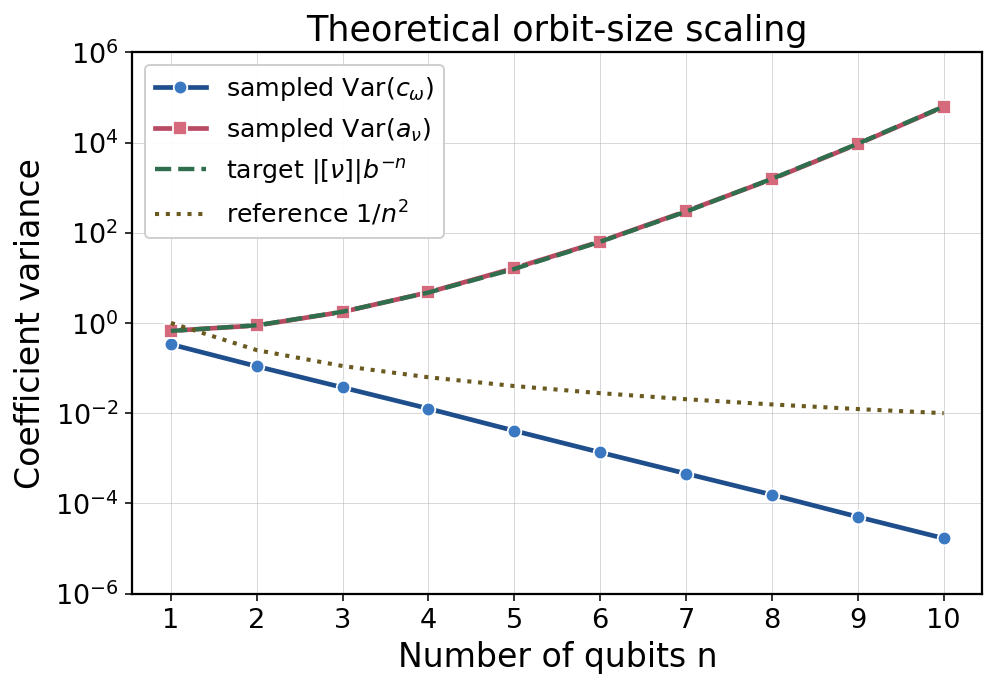

saved figure to /Users/letao/DataSpellProjects/quantum-fourier-expressivity/Paper_work/MSQE/figures/constructed_overcome_vanishing.png


In [166]:
def constructed_k_for_n(n, k_rule="all"):
    if k_rule == "all":
        return int(n)
    if k_rule == "half":
        return int(math.ceil(n / 2))
    if callable(k_rule):
        return int(k_rule(int(n)))
    return int(k_rule)


def constructed_orbit_size(n, k):
    if not (0 <= k <= n):
        raise ValueError(f"Need 0 <= k <= n, got n={n}, k={k}.")
    return (2**k) * math.factorial(n) // math.factorial(n - k)


def complex_gaussian_samples(rng, variance, shape):
    return (rng.normal(size=shape) + 1j * rng.normal(size=shape)) * np.sqrt(variance / 2.0)


def plot_constructed_overcome_demo(
    n_values=None,
    k_rule="all",
    b=3.0,
    c_power=2.0,
    n_mc_samples=4096,
    seed=5,
    max_explicit_orbit_size=200_000,
    show_polynomial_floor=True,
    output_path=None,
):
    """Coefficient-level construction using |[nu_{n,k}]| = 2^k n!/(n-k)!.

    The sampled aggregate is a_nu = sum_{omega in [nu]} c_omega. For very large
    orbits we sample the equivalent complex Gaussian law directly, avoiding a
    huge explicit coefficient matrix.
    """
    if n_values is None:
        n_values = np.arange(1, 11, dtype=int)
    else:
        n_values = np.array(n_values, dtype=int)
    if output_path is None:
        output_path = PAPER_WORK / "MSQE" / "figures" / "constructed_overcome_vanishing.png"

    rng = np.random.default_rng(seed)
    k_values = np.array([constructed_k_for_n(n, k_rule) for n in n_values], dtype=int)
    single_var_exact = b ** (-n_values.astype(float))
    orbit_sizes = np.array(
        [constructed_orbit_size(int(n), int(k)) for n, k in zip(n_values, k_values)],
        dtype=object,
    )
    aggregate_var_exact = np.array(
        [float(orbit_size) * single_var for orbit_size, single_var in zip(orbit_sizes, single_var_exact)],
        dtype=float,
    )
    polynomial_floor = 1.0 / np.maximum(n_values.astype(float) ** c_power, 1.0)

    single_var_empirical = []
    aggregate_var_empirical = []
    sampling_modes = []
    for single_var, orbit_size, aggregate_var in zip(single_var_exact, orbit_sizes, aggregate_var_exact):
        orbit_size_int = int(orbit_size)
        c_samples = complex_gaussian_samples(rng, single_var, n_mc_samples)
        single_var_empirical.append(complex_sample_variance(c_samples, axis=0))

        if orbit_size_int <= max_explicit_orbit_size:
            orbit_coeff_samples = complex_gaussian_samples(rng, single_var, (n_mc_samples, orbit_size_int))
            a_samples = orbit_coeff_samples.sum(axis=1)
            sampling_modes.append("explicit sum")
        else:
            a_samples = complex_gaussian_samples(rng, aggregate_var, n_mc_samples)
            sampling_modes.append("Gaussian sum law")
        aggregate_var_empirical.append(complex_sample_variance(a_samples, axis=0))

    single_var_empirical = np.array(single_var_empirical, dtype=float)
    aggregate_var_empirical = np.array(aggregate_var_empirical, dtype=float)

    print("n | k | orbit size | Var(c_omega) exact | target Var(a_nu) | sampled/target | sampling")
    for n, k, orbit_size, vc, target, sampled, mode in zip(
        n_values,
        k_values,
        orbit_sizes,
        single_var_exact,
        aggregate_var_exact,
        aggregate_var_empirical,
        sampling_modes,
    ):
        print(
            f"{n:2d} | {k:2d} | {int(orbit_size):10d} | "
            f"{vc:17.4e} | {target:16.4e} | {sampled/target:14.4f} | {mode}"
        )
    if show_polynomial_floor:
        print("\nPolynomial floor 1/n^p is only a lower-bound reference, not the target of this toy model.")

    fig, ax = plt.subplots(figsize=(7.0, 4.8), constrained_layout=True)
    ax.plot(
        n_values,
        single_var_empirical,
        "o-",
        color="#1E4E8C",
        markerfacecolor="#3B78C2",
        markeredgecolor="white",
        markeredgewidth=0.9,
        linewidth=2.4,
        markersize=7.0,
        label=r"sampled $\operatorname{Var}(c_\omega)$",
    )
    ax.plot(
        n_values,
        aggregate_var_empirical,
        "s-",
        color="#B84A62",
        markerfacecolor="#D56A7D",
        markeredgecolor="white",
        markeredgewidth=0.9,
        linewidth=2.4,
        markersize=7.0,
        label=r"sampled $\operatorname{Var}(a_\nu)$",
    )
    ax.plot(
        n_values,
        aggregate_var_exact,
        "--",
        color="#2F6F4E",
        linewidth=2.25,
        label=r"target $|[\nu]|b^{-n}$",
    )
    if show_polynomial_floor:
        ax.plot(
            n_values,
            polynomial_floor,
            ":",
            color="#6A5A1F",
            linewidth=2.1,
            label=rf"reference $1/n^{{{c_power:g}}}$",
        )

    ax.set_yscale("log")
    ax.set_xlabel("Number of qubits n")
    ax.set_ylabel("Coefficient variance")
    ax.set_title("Theoretical orbit-size scaling")
    ax.grid(True, which="both", linewidth=0.45, alpha=0.55)
    ax.legend(loc="best", frameon=True, framealpha=0.95)
    ax.set_xticks(n_values.astype(int))

    positive_values = [single_var_empirical, aggregate_var_empirical, aggregate_var_exact]
    if show_polynomial_floor:
        positive_values.append(polynomial_floor)
    positive_values = np.concatenate(positive_values)
    positive_values = positive_values[np.isfinite(positive_values) & (positive_values > 0)]
    if positive_values.size:
        y_min = 10 ** np.floor(np.log10(np.min(positive_values)) - 0.25)
        y_max = 10 ** np.ceil(np.log10(np.max(positive_values)) + 0.25)
        ax.set_ylim(y_min, y_max)

    output_path.parent.mkdir(parents=True, exist_ok=True)
    fig.savefig(output_path, dpi=300, bbox_inches="tight")
    plt.show()
    print(f"saved figure to {output_path}")
    return {
        "n_values": n_values,
        "k_values": k_values,
        "orbit_sizes": np.array([int(orbit_size) for orbit_size in orbit_sizes], dtype=object),
        "single_var_exact": single_var_exact,
        "aggregate_var_exact": aggregate_var_exact,
        "polynomial_floor": polynomial_floor,
        "single_var_empirical": single_var_empirical,
        "aggregate_var_empirical": aggregate_var_empirical,
        "sampling_modes": sampling_modes,
    }


constructed_results = plot_constructed_overcome_demo(k_rule="all", b=3.0, c_power=2.0)


## Reading the Diagnostics

- `ratio` is $\operatorname{Var}(a_{\nu_n})/\overline{\operatorname{Var}(c_\omega)}_{\omega\in[\nu_n]}$.
- `ratio/orbit` close to one means the empirical ratio follows the ideal 2-design scaling for the selected orbit size $|[\nu_n]|$.
- `Var(a)/sum Var(c)` close to one means orbit coefficients are effectively decoupled. If this number is far from one, the difference is caused by covariance between coefficients in the selected orbit.
- By default, $\nu_n=(1,2,\ldots,n)$, so $|[\nu_n]|=2^n n!$.
- The two circuit settings compared here are StrongEntangle-style trainable layers with `B=n` blocks and `B=1` block.
- The final theoretical scaling cell is not a circuit run. Its target is $|[\nu]|b^{-n}$; the $1/n^p$ curve is only a reference lower-bound scale.
- Increase `n_parameter_samples` for a smoother circuit curve; runtime is roughly linear in this value.
